In [3]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/dataset")

assert (DATA_DIR / "train.csv").exists(), f"Not found: {DATA_DIR / 'train.csv'}"
print("Using:", DATA_DIR.resolve())

Mounted at /content/drive
Using: /content/drive/MyDrive/dataset


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13

In [5]:
train = pd.read_csv(DATA_DIR / "train.csv")
dev = pd.read_csv(DATA_DIR / "dev.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

for df in (train, dev, test):
    df.drop(
        columns=[c for c in df.columns if str(c).startswith("Unnamed")],
        inplace=True,
        errors="ignore",
    )

for name, df in [("train", train), ("dev", dev), ("test", test)]:
    print(f"\n=== {name.upper()} ===")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head())

cols_needed = ["article", "question", "A", "B", "C", "D", "answer"]
for name, df in [("train", train), ("dev", dev), ("test", test)]:
    print(f"\n{name} — null counts:\n{df[cols_needed].isnull().sum()}")

allowed = {"A", "B", "C", "D"}
for name, df in [("train", train), ("dev", dev), ("test", test)]:
    bad = sorted(df.loc[~df["answer"].isin(allowed), "answer"].dropna().unique().tolist())
    print(f"{name}: invalid answer labels: {bad}")


=== TRAIN ===
Shape: (87866, 8)
Columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


,id,article,question,A,B,C,D,answer
0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B
2,middle4305.txt,A bumpkin went to a big city for the first t...,The bumpkin thought _ .,his wife was as beautiful as the young girl,his wife was more beautiful than the short fat...,the short fat woman changed to a young girl in...,He should also buy a room of that kind for his...,C
3,middle4305.txt,A bumpkin went to a big city for the first t...,The room he saw was perhaps _ .,an office,a toilet,a lift,a helicopter,C
4,middle4305.txt,A bumpkin went to a big city for the first t...,We can see that the bumpkin had no knowledge ...,farming or gardening,how to do farm work,how to live in a city,modern city life,D



=== DEV ===
Shape: (87866, 8)
Columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


,id,article,question,A,B,C,D,answer
0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B
2,middle4305.txt,A bumpkin went to a big city for the first t...,The bumpkin thought _ .,his wife was as beautiful as the young girl,his wife was more beautiful than the short fat...,the short fat woman changed to a young girl in...,He should also buy a room of that kind for his...,C
3,middle4305.txt,A bumpkin went to a big city for the first t...,The room he saw was perhaps _ .,an office,a toilet,a lift,a helicopter,C
4,middle4305.txt,A bumpkin went to a big city for the first t...,We can see that the bumpkin had no knowledge ...,farming or gardening,how to do farm work,how to live in a city,modern city life,D



=== TEST ===
Shape: (87866, 8)
Columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


,id,article,question,A,B,C,D,answer
0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B
2,middle4305.txt,A bumpkin went to a big city for the first t...,The bumpkin thought _ .,his wife was as beautiful as the young girl,his wife was more beautiful than the short fat...,the short fat woman changed to a young girl in...,He should also buy a room of that kind for his...,C
3,middle4305.txt,A bumpkin went to a big city for the first t...,The room he saw was perhaps _ .,an office,a toilet,a lift,a helicopter,C
4,middle4305.txt,A bumpkin went to a big city for the first t...,We can see that the bumpkin had no knowledge ...,farming or gardening,how to do farm work,how to live in a city,modern city life,D



train — null counts:
article     0
question    0
A           4
B           0
C           1
D           9
answer      0
dtype: int64

dev — null counts:
article     0
question    0
A           4
B           0
C           1
D           9
answer      0
dtype: int64

test — null counts:
article     0
question    0
A           4
B           0
C           1
D           9
answer      0
dtype: int64
train: invalid answer labels: []
dev: invalid answer labels: []
test: invalid answer labels: []


In [6]:
OPTION_COLS = ["A", "B", "C", "D"]


def word_count(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())


def question_type(q):
    if pd.isna(q):
        return "Other"
    first = str(q).strip().split(maxsplit=1)[0]
    key = first.strip(":_\"'""''?!").lower().capitalize()
    starters = {"Who", "What", "Where", "When", "Why", "How", "Which"}
    return key if key in starters else "Other"


train = train.copy()
train["_wc_article"] = train["article"].map(word_count)
train["_wc_question"] = train["question"].map(word_count)
train["_qtype"] = train["question"].map(question_type)

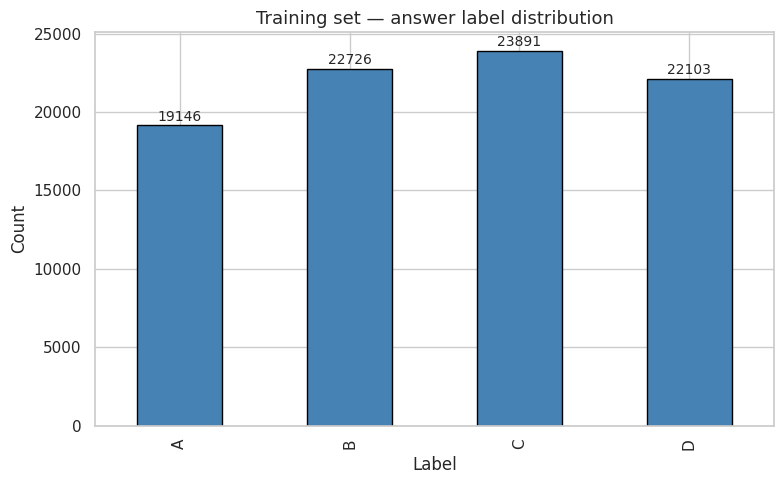

answer
A    19146
B    22726
C    23891
D    22103
Name: count, dtype: int64
Proportions:
 answer
A    0.2179
B    0.2586
C    0.2719
D    0.2516
Name: count, dtype: float64


In [7]:
counts = train["answer"].value_counts().reindex(["A", "B", "C", "D"]).fillna(0).astype(int)

ax = counts.plot(kind="bar", color="steelblue", edgecolor="black")
ax.set_title("Training set — answer label distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ymax = counts.max()
for i, v in enumerate(counts):
    ax.text(i, v + ymax * 0.005, str(int(v)), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

print(counts)
print("Proportions:\n", (counts / counts.sum()).round(4))

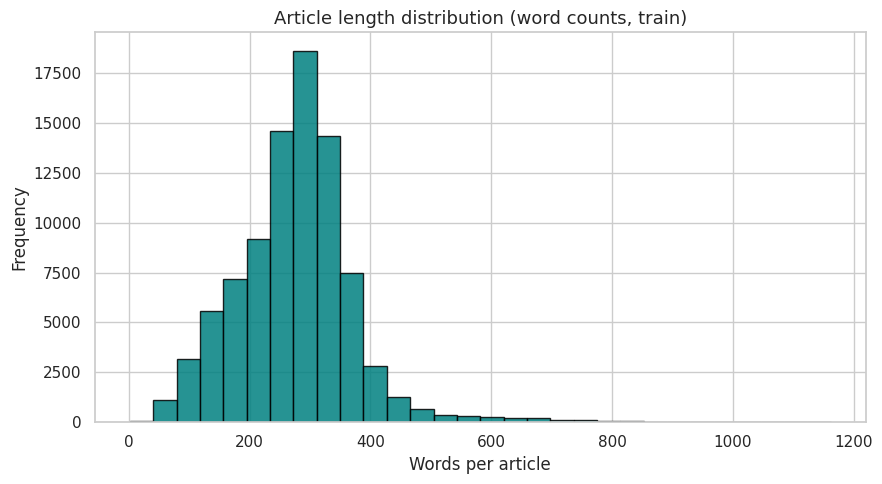

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(train["_wc_article"], bins=30, color="teal", edgecolor="black", alpha=0.85)
plt.title("Article length distribution (word counts, train)")
plt.xlabel("Words per article")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

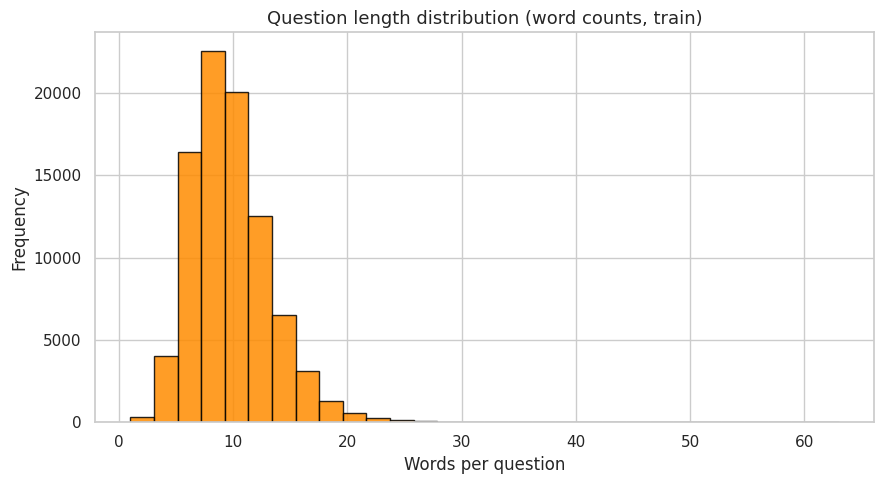

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(train["_wc_question"], bins=30, color="darkorange", edgecolor="black", alpha=0.85)
plt.title("Question length distribution (word counts, train)")
plt.xlabel("Words per question")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

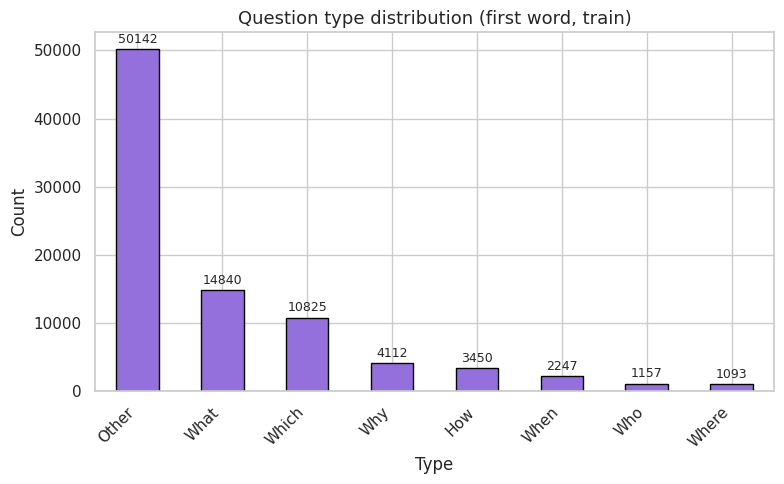

In [10]:
qt_counts = train["_qtype"].value_counts()
ax = qt_counts.plot(kind="bar", color="mediumpurple", edgecolor="black")
ax.set_title("Question type distribution (first word, train)")
ax.set_xlabel("Type")
ax.set_ylabel("Count")
qm = qt_counts.max()
for i, v in enumerate(qt_counts):
    ax.text(i, v + qm * 0.01, str(int(v)), ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

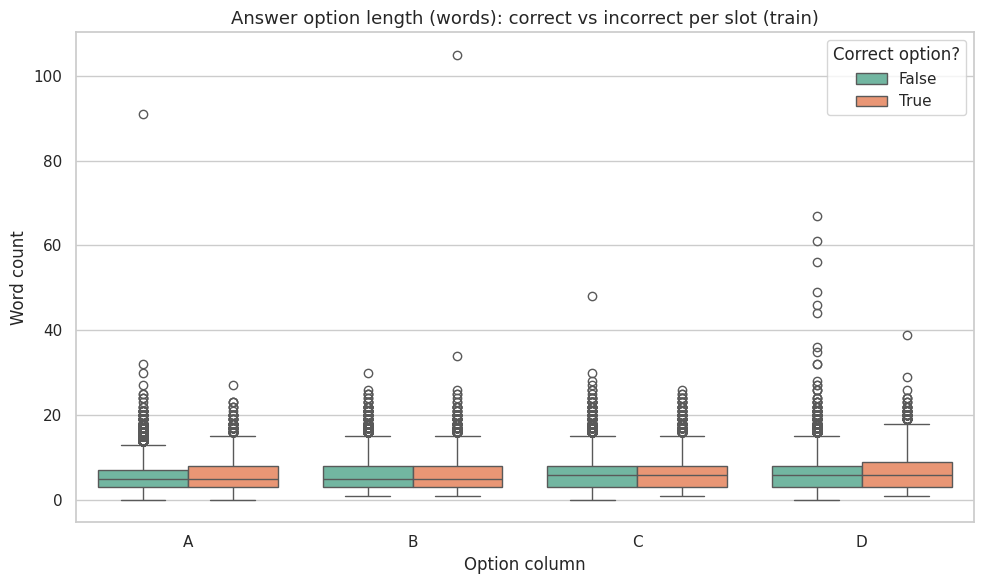

In [11]:
rows = []
for _, r in train.iterrows():
    ans = r["answer"]
    for opt in OPTION_COLS:
        rows.append({"option_slot": opt, "wc": word_count(r[opt]), "is_correct": opt == ans})
opt_long = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))
sns.boxplot(data=opt_long, x="option_slot", y="wc", hue="is_correct", palette="Set2")
plt.title("Answer option length (words): correct vs incorrect per slot (train)")
plt.xlabel("Option column")
plt.ylabel("Word count")
plt.legend(title="Correct option?")
plt.tight_layout()
plt.show()

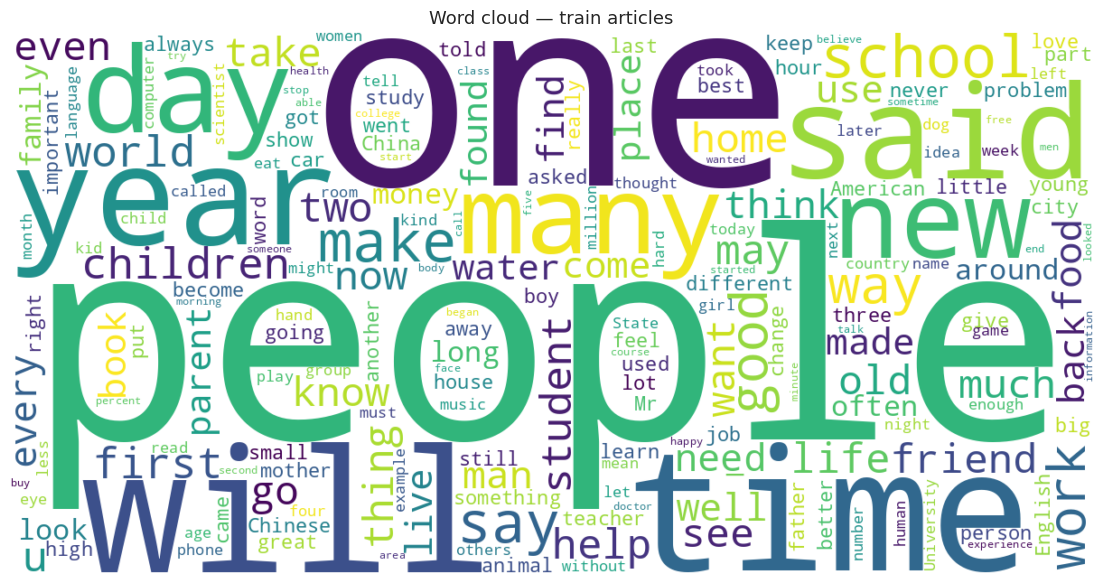

In [12]:
from wordcloud import WordCloud

text_corpus = " ".join(train["article"].astype(str))
wc = WordCloud(width=1200, height=600, background_color="white", collocations=False).generate(text_corpus)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word cloud — train articles")
plt.tight_layout()
plt.show()

In [15]:
def summarize_series(s):
    return pd.Series(
        {"mean": s.mean(), "median": s.median(), "min": s.min(), "max": s.max(), "std": s.std()}
    )


def vocab_size_articles(series):
    vocab = set()
    for t in series.astype(str):
        vocab.update(t.lower().split())
    return len(vocab)


opt_wc_all = []
for _, r in train.iterrows():
    for opt in OPTION_COLS:
        opt_wc_all.append(word_count(r[opt]))
opt_wc_series = pd.Series(opt_wc_all)

summary_df = pd.DataFrame(
    {
        "article_word_count": summarize_series(train["_wc_article"]),
        "question_word_count": summarize_series(train["_wc_question"]),
        "answer_option_word_count": summarize_series(opt_wc_series),
    }
)
summary_df.loc["vocab_unique_words_train_articles"] = {
    "article_word_count": vocab_size_articles(train["article"]),
    "question_word_count": np.nan,
    "answer_option_word_count": np.nan,
}

display(summary_df.round(3))

,article_word_count,question_word_count,answer_option_word_count
mean,274.984,10.009,5.706
median,279.000,10.000,5.000
min,2.000,1.000,0.000
max,1162.000,63.000,105.000
std,97.881,3.382,3.443
vocab_unique_words_train_articles,245057.000,NaN,NaN


In [16]:
print("\n--- Tiny articles (≤ 30 words) ---")
print(train.loc[train["_wc_article"] <= 30, ["id", "article", "question"]].head(10))

print("\n--- Empty / 1-word questions ---")
print(train.loc[train["_wc_question"] <= 1, ["id", "question"]].head(10))

print("\n--- Empty options ---")
mask_empty = (train[OPTION_COLS].astype(str).map(lambda s: len(s.split())) == 0).any(axis=1)
print("Rows with at least one empty option:", mask_empty.sum())
print(train.loc[mask_empty, ["id"] + OPTION_COLS].head(5))

print("\n--- Very long options (> 30 words) ---")
long_opt_mask = (train[OPTION_COLS].astype(str).map(lambda s: len(s.split())) > 30).any(axis=1)
print("Rows with at least one >30-word option:", long_opt_mask.sum())


--- Tiny articles (≤ 30 words) ---
                  id                                            article  \
2934  middle5352.txt  The Cuckoo\nIn April,\nCome he will.\nIn May,\...   
2935  middle5352.txt  The Cuckoo\nIn April,\nCome he will.\nIn May,\...   
2936  middle5352.txt  The Cuckoo\nIn April,\nCome he will.\nIn May,\...   
8459  middle7072.txt  Somepeoplethinkthatsingingcanliftourspirits ,w...   
8460  middle7072.txt  Somepeoplethinkthatsingingcanliftourspirits ,w...   
8461  middle7072.txt  Somepeoplethinkthatsingingcanliftourspirits ,w...   
9550  middle8028.txt                                          Passage 1   
9551  middle8028.txt                                          Passage 1   
9552  middle8028.txt                                          Passage 1   
9553  middle8028.txt                                          Passage 1   

                                               question  
2934                    What does the cuckoo do in May?  
2935                  

In [17]:
print("Sample of 'Other'-type questions (likely cloze stems):\n")
for q in train.loc[train["_qtype"] == "Other", "question"].sample(20, random_state=42):
    print("•", q)

Sample of 'Other'-type questions (likely cloze stems):

• The passage is probably written for  _  .
• You are at the Museum at seven in the evening and you want to go back to Oxford. Which means of transportation will you choose?
• Parents with large families ask fewer questions at dinner because  _  .
• A loyal best friend must   _   according to the passage.
• The waitress was   _   when the boy studied his coins.
• Baby boys and girls have different toy preferences probably because  .
• The shop owner insisted  that the trousers were worth only two dollars because  _  .
• The main purpose of the article is to   _  .
• The passage suggests that  _  .
• According to the author, a new language   _  .
• Hallyu is very hot in Asia partly because  _  .
• At present Santa Fe belongs to  _  .
• Country music is usually about   _  .
• The two pieces of advice suggest that planting is closely related to  _
• After reading the story what can we infer about the hospital?   _
• What's the writer

In [18]:
def label_dist(df):
    return df["answer"].value_counts(normalize=True).reindex(["A","B","C","D"]).round(4)

dist = pd.DataFrame({
    "train": label_dist(train),
    "dev":   label_dist(dev),
    "test":  label_dist(test),
})
print(dist)

         train     dev    test
answer                        
A       0.2179  0.2179  0.2179
B       0.2586  0.2586  0.2586
C       0.2719  0.2719  0.2719
D       0.2516  0.2516  0.2516


count    87866.000000
mean        16.905481
std          7.503893
min          1.000000
25%         12.000000
50%         16.000000
75%         21.000000
max        101.000000
Name: _sent_count, dtype: float64


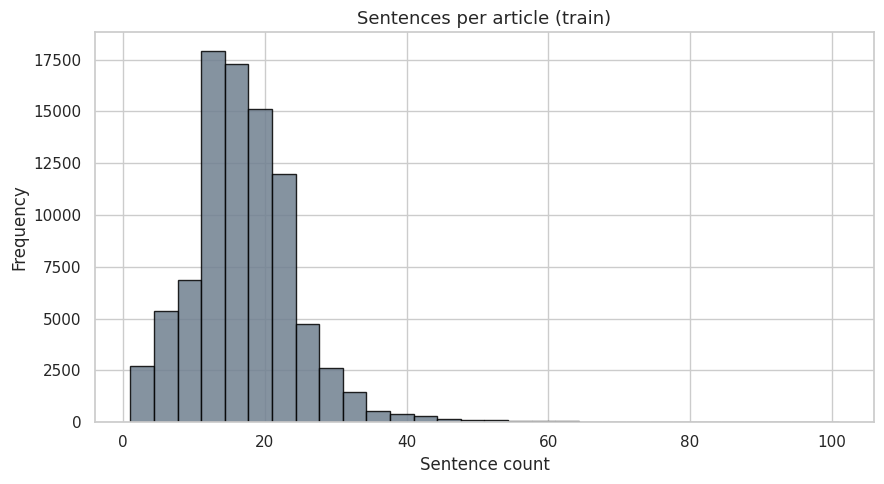

In [19]:
import re

def sentence_count(t):
    return len(re.split(r"(?<=[.!?])\s+", str(t).strip()))

train["_sent_count"] = train["article"].map(sentence_count)
print(train["_sent_count"].describe())

plt.figure(figsize=(9,5))
plt.hist(train["_sent_count"], bins=30, color="slategray", edgecolor="black", alpha=0.85)
plt.title("Sentences per article (train)")
plt.xlabel("Sentence count"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

In [20]:
print("Unique articles by id:", train["id"].nunique())
print("Total rows:", len(train))
print("Avg questions per article:", round(len(train) / train["id"].nunique(), 2))

per_article = train.groupby("id").size()
print(per_article.describe())

Unique articles by id: 25135
Total rows: 87866
Avg questions per article: 3.5
count    25135.000000
mean         3.495763
std          0.974802
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          7.000000
dtype: float64


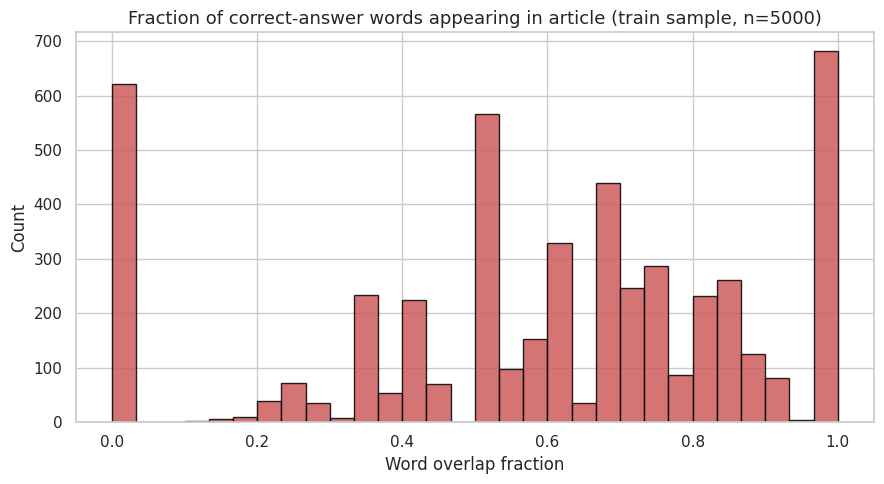

count    5000.000000
mean        0.587495
std         0.299028
min         0.000000
25%         0.428571
50%         0.625000
75%         0.800000
max         1.000000
Name: _overlap, dtype: float64


In [21]:
def overlap_correct_with_article(row):
    art_words = set(str(row["article"]).lower().split())
    correct = str(row[row["answer"]]).lower().split() if row["answer"] in OPTION_COLS else []
    if not correct:
        return 0.0
    return sum(1 for w in correct if w in art_words) / len(correct)

sample = train.sample(5000, random_state=42).copy()
sample["_overlap"] = sample.apply(overlap_correct_with_article, axis=1)

plt.figure(figsize=(9,5))
plt.hist(sample["_overlap"], bins=30, color="indianred", edgecolor="black", alpha=0.85)
plt.title("Fraction of correct-answer words appearing in article (train sample, n=5000)")
plt.xlabel("Word overlap fraction"); plt.ylabel("Count")
plt.tight_layout(); plt.show()
print(sample["_overlap"].describe())